## Dashen Bank Review Analysis

Import Required Libraries

In [26]:
import sys
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_2\fintech-review-analytics


In [27]:
# Core libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from collections import Counter
from wordcloud import WordCloud
from datetime import datetime
from google_play_scraper import app, reviews, Sort

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

from src.data_scrapper import scrape_metadata, scrape_reviews, data_quality_check
from src.data_preprocessor import missing_values, duplicate_reviews, check_dateFormat, missing_values, normalize_date, clean_text, invalid_reviews, remove_duplicates, save_cleaned_data, preprocessing_report
from src.modular_nlp_pipeline import modular_nlp_pipeline

print("Libraries loaded successfully!")

Environment ready ✓
Libraries loaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Defining Variables

In [28]:
App_Id = "com.dashen.dashensuperapp"
bank = 'Dashen Bank'
source = 'Google Play Store'
print(f" Scraping Review for Bank: {bank} with App ID: {App_Id} from Source: {source}")


 Scraping Review for Bank: Dashen Bank with App ID: com.dashen.dashensuperapp from Source: Google Play Store


## Mobile App Review Data Scraping from Google Play Store

In [29]:
# Get meta data for the app
scrape_metadata(App_Id, bank)

App Info for Dashen Bank
App Title   : Dashen Bank
Current Score: 4.2612457
Total Ratings: 5,665
Total Reviews: 1,024
Installs     : 1,000,000+


{'title': 'Dashen Bank',
 'description': 'Why choose Dashen Bank Super App?\r\n• Secure & Reliable: Built with robust security to protect your financial transactions.\r\n• Convenient: Manage your accounts, pay bills, and access essential services in one place.\r\n• User-Friendly: Simplified design for seamless navigation and usage.',
 'descriptionHTML': 'Why choose Dashen Bank Super App?<br>• Secure &amp; Reliable: Built with robust security to protect your financial transactions.<br>• Convenient: Manage your accounts, pay bills, and access essential services in one place.<br>• User-Friendly: Simplified design for seamless navigation and usage.',
 'summary': 'Bank smarter, pay bills easily, and access essential lifestyle services',
 'installs': '1,000,000+',
 'minInstalls': 1000000,
 'realInstalls': 1530676,
 'score': 4.2612457,
 'ratings': 5665,
 'reviews': 1024,
 'histogram': [597, 264, 294, 411, 4096],
 'price': 0,
 'free': True,
 'currency': 'USD',
 'sale': False,
 'saleTime': None

In [30]:
#scrape 500 reviews for the app
df_reviews, continuation_token = scrape_reviews(App_Id, bank, count=500)
df_reviews = pd.DataFrame(df_reviews)

Collected 500 raw reviews for Dashen Bank app.


In [31]:
print(type(df_reviews))

<class 'pandas.DataFrame'>


In [32]:
print(df_reviews.head())
print(df_reviews.columns)

                               reviewId          userName  \
0  12ebd51a-7912-464b-a81b-14a0aac358da  Jaalataa Gazaali   
1  68dd84a3-07ab-41d9-aff8-ad7916ff71a8   Hayredin Redwan   
2  78284116-8313-4ca8-a28c-61ce4fa44ee6         king mele   
3  b4a7ea95-727b-4501-8d84-77db88187c84        Ahmed Abdi   
4  59a20f9e-bb87-4d5f-bee7-ce19f19baddf           Bellixs   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-U...   
1  https://play-lh.googleusercontent.com/a-/ALV-U...   
2  https://play-lh.googleusercontent.com/a/ACg8oc...   
3  https://play-lh.googleusercontent.com/a/ACg8oc...   
4  https://play-lh.googleusercontent.com/a-/ALV-U...   

                                             content  score  thumbsUpCount  \
0                                                 ok      5              0   
1                         best app so far. thank you      5              0   
2  Very Annoying App i tried to open virtual bank...      1   

In [33]:
# Inspect what a single raw review looks like

print("Keys in a single review:")
print(list(df_reviews.iloc[0].keys()))

print("\nFirst raw review (sample):")
for key, value in df_reviews.iloc[0].items():
    print(f"  {key}: {value}")

Keys in a single review:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']

First raw review (sample):
  reviewId: 12ebd51a-7912-464b-a81b-14a0aac358da
  userName: Jaalataa Gazaali
  userImage: https://play-lh.googleusercontent.com/a-/ALV-UjXO44wE9dZ0Om9g5Xqk8NSMmFdDyW3Q5_-ZxucwwRSVPbBQBf1n
  content: ok
  score: 5
  thumbsUpCount: 0
  reviewCreatedVersion: 1.9.04
  at: 2026-05-15 13:41:19
  replyContent: nan
  repliedAt: NaT
  appVersion: 1.9.04


In [34]:
# Step 3: Extract only the columns we need
raw_data = []

for r in df_reviews.itertuples():
    raw_data.append({
        'review_id': r.reviewId,
        'review'   : r.content,
        'rating'   : r.score,
        'date'     : r.at,
        'bank'     : bank,
        'source'   : 'Google Play'
    })

# Build a DataFrame
df_raw = pd.DataFrame(raw_data)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (500, 6)


,review_id,review,rating,date,bank,source
0,12ebd51a-7912-464b-a81b-14a0aac358da,ok,5,2026-05-15 13:41:19,Dashen Bank,Google Play
1,68dd84a3-07ab-41d9-aff8-ad7916ff71a8,best app so far. thank you,5,2026-05-15 11:33:32,Dashen Bank,Google Play
2,78284116-8313-4ca8-a28c-61ce4fa44ee6,Very Annoying App i tried to open virtual bank...,1,2026-05-14 12:33:42,Dashen Bank,Google Play
3,b4a7ea95-727b-4501-8d84-77db88187c84,good,5,2026-05-14 12:26:20,Dashen Bank,Google Play
4,59a20f9e-bb87-4d5f-bee7-ce19f19baddf,good,5,2026-05-14 10:35:20,Dashen Bank,Google Play


## Exploring the Raw Data

In [35]:
# Basic shape and types
print(f"Total reviews collected: {len(df_raw)}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes)

Total reviews collected: 500

Column dtypes:
review_id               str
review                  str
rating                int64
date         datetime64[us]
bank                    str
source                  str
dtype: object


In [36]:
print("Rating Distribution:")
rating_counts = df_raw['rating'].value_counts().sort_index(ascending=False)
for rating, count in rating_counts.items():
    bar = '█' * (count // 4) 
    print(f"{rating} stars: {bar} ({count} reviews)")


Rating Distribution:
5 stars: ████████████████████████████████████████████████████████████████████████████████ (323 reviews)
4 stars: ████████ (33 reviews)
3 stars: ██████ (27 reviews)
2 stars: ████ (19 reviews)
1 stars: ████████████████████████ (98 reviews)


In [37]:
# What does the date column look like right now?
print("Sample date values (raw):")
print(df_raw['date'].head(10).to_string())

print(f"\nDate dtype: {df_raw['date'].dtype}")

Sample date values (raw):
0   2026-05-15 13:41:19
1   2026-05-15 11:33:32
2   2026-05-14 12:33:42
3   2026-05-14 12:26:20
4   2026-05-14 10:35:20
5   2026-05-14 10:29:26
6   2026-05-14 09:15:23
7   2026-05-14 08:58:59
8   2026-05-14 08:19:29
9   2026-05-13 12:14:11

Date dtype: datetime64[us]


## Data Quality Audit

In [38]:
data_quality_check(df_raw)

Data Quality Check:
------------------------------
Total reviews collected: 500
Missing values per column:
review_id    0
review       0
rating       0
date         0
bank         0
source       0
dtype: int64


In [39]:
missing_values(df_raw)

Removed 0 rows with missing critical data
Remaining: 500 reviews


,review_id,review,rating,date,bank,source
0,12ebd51a-7912-464b-a81b-14a0aac358da,ok,5,2026-05-15 13:41:19,Dashen Bank,Google Play
1,68dd84a3-07ab-41d9-aff8-ad7916ff71a8,best app so far. thank you,5,2026-05-15 11:33:32,Dashen Bank,Google Play
2,78284116-8313-4ca8-a28c-61ce4fa44ee6,Very Annoying App i tried to open virtual bank...,1,2026-05-14 12:33:42,Dashen Bank,Google Play
3,b4a7ea95-727b-4501-8d84-77db88187c84,good,5,2026-05-14 12:26:20,Dashen Bank,Google Play
4,59a20f9e-bb87-4d5f-bee7-ce19f19baddf,good,5,2026-05-14 10:35:20,Dashen Bank,Google Play
...,...,...,...,...,...,...
495,dc8432b9-7fd6-4ada-9ca6-b632467fcf15,It was easy enough before. but now it won't ev...,3,2025-08-14 13:00:15,Dashen Bank,Google Play
496,35fc8b13-0a39-4237-b28d-39904b57f125,good,5,2025-08-14 09:14:19,Dashen Bank,Google Play
497,5043e566-8cbc-4384-9382-8d929065614e,There are plenty of features missed e. g elect...,2,2025-08-14 08:16:24,Dashen Bank,Google Play
498,0269ed2c-74ca-4b44-8226-0a664489ac78,የሶፍትዌሩ ለአጠቃቀም ምቹና ቀላል መሆኑ ተመራጭ ያደርገዋል,5,2025-08-14 06:56:25,Dashen Bank,Google Play


Check for Duplicates

In [40]:
duplicate_reviews(df_raw)

Duplicate reviews:
------------------------------
Total duplicate review IDs: 0
Total duplicate review texts: 94
Total empty reviews: 0
Total duplicate reviews: 0


In [41]:
# Copying the raw DataFrame to work on a clean version
df = df_raw.copy()
print("Data copied for preprocessing.")

Data copied for preprocessing.


Remove Missing Data

In [42]:
df = missing_values(df)

Removed 0 rows with missing critical data
Remaining: 500 reviews


Remove Duplicates

In [43]:
df = remove_duplicates(df)

Removed 0 duplicate reviews based on review_id
Remaining: 500 reviews


Normalize Date

In [44]:
check_dateFormat(df)
df = normalize_date(df)


Checking date format:
------------------------------
Sample dates: 2026-05-15 13:41:19
Data type of 'date' column: datetime64[us]
  Target format: YYYY-MM-DD (string or date object)
Dates normalized to YYYY-MM-DD format
dtype: str

Date range: 2025-08-14 to 2026-05-15


Clean white spaces

In [45]:
df = clean_text(df)

Remove Invalid Reviews

In [46]:
df = invalid_reviews(df) 

Invalid ratings (outside 1–5): 0
Remaining reviews after removing invalid ratings: 500
Data type of 'rating' column: int64


## Cleaned Data

In [47]:
# Select only the 5 required columns in the right order
df_clean = df[['review', 'rating', 'date', 'bank', 'source']].copy()

# Sort by date (newest first) for clean presentation
df_clean = df_clean.sort_values('date', ascending=False).reset_index(drop=True)

print(f"Final dataset shape: {df_clean.shape}")
df_clean.head(10)

Final dataset shape: (500, 5)


,review,rating,date,bank,source
0,ok,5,2026-05-15,Dashen Bank,Google Play
1,best app so far. thank you,5,2026-05-15,Dashen Bank,Google Play
2,Very Annoying App i tried to open virtual bank...,1,2026-05-14,Dashen Bank,Google Play
3,good,5,2026-05-14,Dashen Bank,Google Play
4,good,5,2026-05-14,Dashen Bank,Google Play
5,good app but it was doesnt work other bank tra...,5,2026-05-14,Dashen Bank,Google Play
6,good,5,2026-05-14,Dashen Bank,Google Play
7,"i swear to god , By using this app, I won a Sa...",5,2026-05-14,Dashen Bank,Google Play
8,good and easier to used,5,2026-05-14,Dashen Bank,Google Play
9,bad mobile banking at all,1,2026-05-13,Dashen Bank,Google Play


Save Cleaned Data

In [48]:
df = save_cleaned_data(df, "dashen_reviews")

Shape of cleaned dashen_reviews: (500, 6)
First 5 rows of cleaned dashen_reviews:
                              review_id  \
0  12ebd51a-7912-464b-a81b-14a0aac358da   
1  68dd84a3-07ab-41d9-aff8-ad7916ff71a8   
2  78284116-8313-4ca8-a28c-61ce4fa44ee6   
3  b4a7ea95-727b-4501-8d84-77db88187c84   
4  59a20f9e-bb87-4d5f-bee7-ce19f19baddf   

                                              review  rating        date  \
0                                                 ok       5  2026-05-15   
1                         best app so far. thank you       5  2026-05-15   
2  Very Annoying App i tried to open virtual bank...       1  2026-05-14   
3                                               good       5  2026-05-14   
4                                               good       5  2026-05-14   

          bank       source  
0  Dashen Bank  Google Play  
1  Dashen Bank  Google Play  
2  Dashen Bank  Google Play  
3  Dashen Bank  Google Play  
4  Dashen Bank  Google Play  


## Report for Data Preprocessing

In [49]:
preprocessing_report(df_raw, df)

  PREPROCESSING REPORT — Reviews

  Raw reviews collected  :    500
  Reviews after cleaning :    500
  Reviews removed        :      0
  Data retention rate    : 100.0%
  Data quality           : EXCELLENT

  Date range : 2025-08-14  to  2026-05-15

  Rating distribution:
    5 stars :  323 (64.6%)  ████████████████████████████████████████████████████████████████
    4 stars :   33 ( 6.6%)  ██████
    3 stars :   27 ( 5.4%)  █████
    2 stars :   19 ( 3.8%)  ███
    1 stars :   98 (19.6%)  ███████████████████

  Text length stats:
    Min    : 1 characters
    Median : 22 characters
    Max    : 499 characters

  Columns in final CSV:
    - review_id
    - review
    - rating
    - date
    - bank
    - source



## Tokenization and Lemmatization

In [51]:
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...
Final cleaned dataset size: 466


## Keyword Extraction

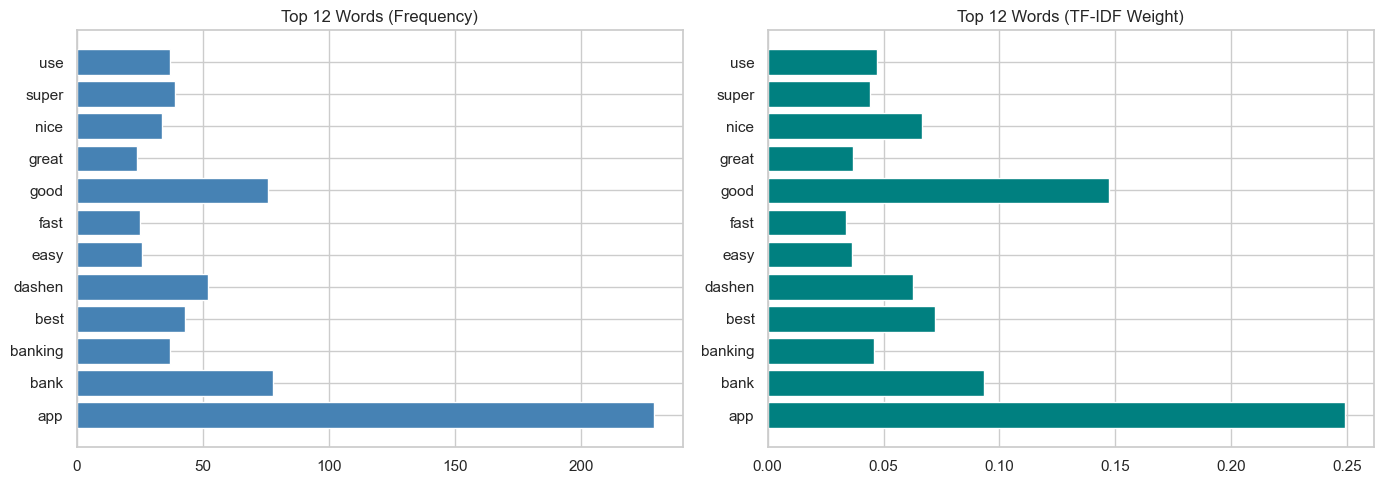

In [52]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

## N-gram Analysis


C:\Users\dagic\AppData\Local\Temp\ipykernel_26440\40103568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
C:\Users\dagic\AppData\Local\Temp\ipykernel_26440\40103568.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')


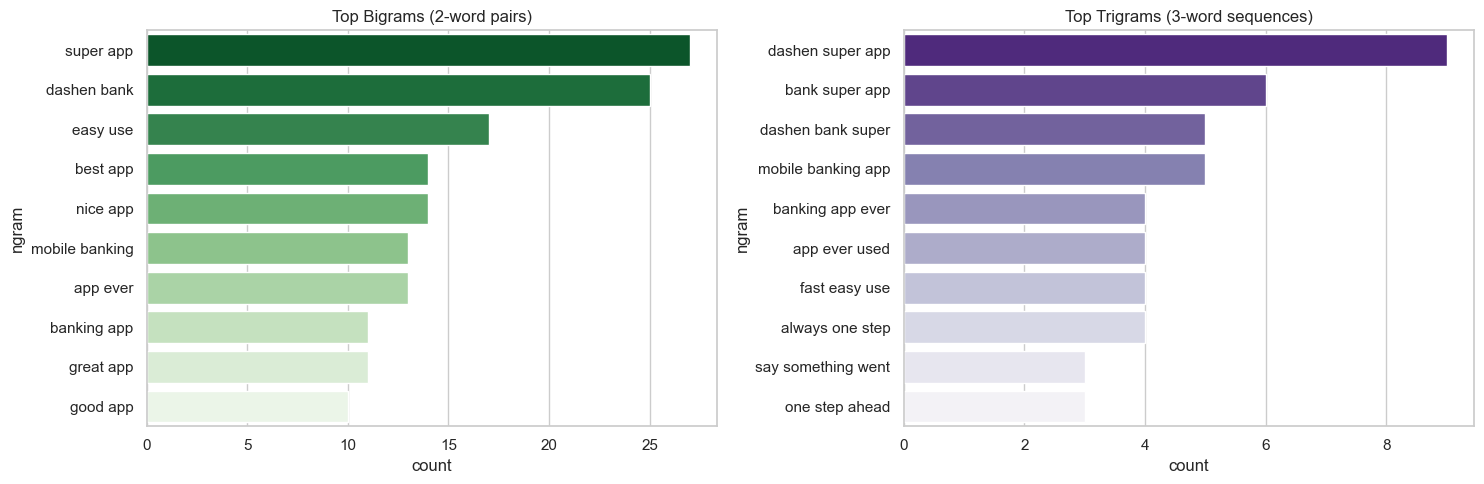

In [53]:
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

## POS Tagging and Noun Extraction

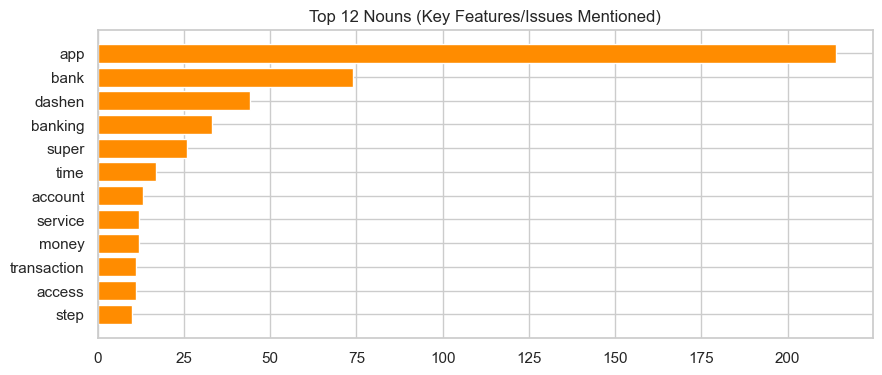

In [54]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Word Cloud

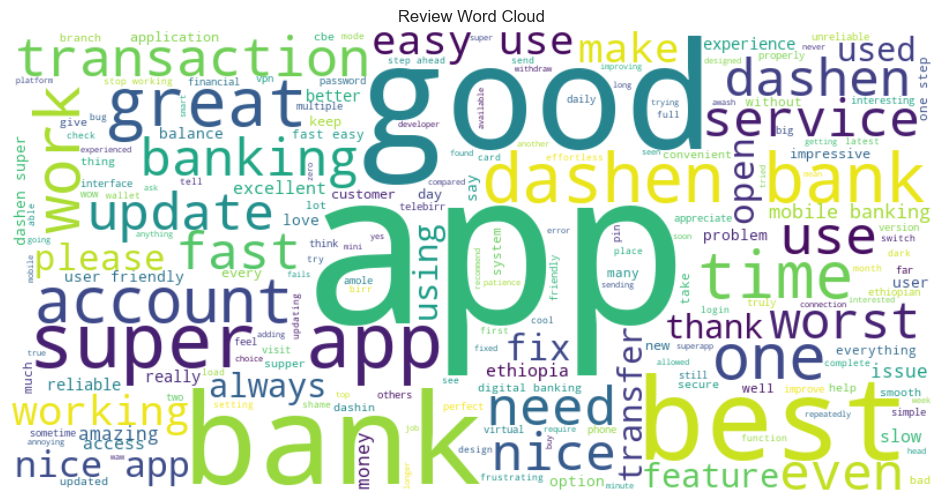

In [55]:
# Cell 8: Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()